# Dimensionality Reduction with PCA

## Overview

This notebook focuses on reducing a high-dimensional dataset with Principal Component Analysis (PCA) while keeping most of the variance in the data.

The workflow is:

1. load and inspect a dataset with many numeric features,
2. standardize the features before PCA,
3. fit PCA across all components,
4. inspect explained variance and cumulative explained variance,
5. choose the smallest number of components that keeps about 95% of the variance,
6. reduce the dataset using that number of components,
7. reduce the same data to two components for visualization,
8. interpret what was preserved and what was lost.

## Why Dimensionality Reduction?

When the number of features increases, every feature adds another dimension to the feature space. In high dimensions, observations can become sparse, distance-based relationships can become less useful, computation becomes more expensive, and models may have more opportunity to overfit.

Dimensionality reduction tries to represent the same observations with fewer dimensions while preserving as much useful structure as possible.

PCA is a feature extraction method rather than feature selection. It does not simply choose a few original columns and delete the rest. Instead, it creates new features called **principal components** from combinations of the original features.

## How PCA Represents the Data

PCA searches for new directions in the feature space:

- **PC1** is the direction where the projected data has the largest variance.
- **PC2** captures the largest remaining variance while being perpendicular to PC1.
- The following components continue in the same way.

Each direction can be represented by an eigenvector. Its values act like weights for the original features. Projecting each sample onto that direction gives the sample's value for that principal component.

The corresponding eigenvalue measures how much variance exists along that component. In practice, `explained_variance_ratio_` is the easier quantity to interpret because it tells me what fraction of the total variance each component explains.

## 1. Imports

I use Scikit-learn's Breast Cancer dataset because it contains 30 numeric features, which makes the dimensionality reduction effect easy to inspect without adding an external data dependency.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 2. Load the Dataset

The dataset includes 30 numeric measurements for each sample and also provides a diagnosis target.

PCA itself is fitted only on the feature matrix `X`. The target is kept separately and used later only to color the 2D visualization so I can inspect whether the reduced representation shows any visible structure.

In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data.copy()
y = data.target.copy()

df = X.copy()
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Basic Inspection

Before applying PCA, I check the dataset shape, missing values, and feature ranges. PCA is affected by scale because it searches for directions with high variance.

In [3]:
print(f"Samples: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Missing values: {X.isna().sum().sum()}")

Samples: 569
Features: 30
Missing values: 0


In [4]:
feature_ranges = pd.DataFrame({
    "min": X.min(),
    "max": X.max(),
    "std": X.std()
})

feature_ranges.head(10)

,min,max,std
mean radius,6.98100,28.11000,3.524049
mean texture,9.71000,39.28000,4.301036
mean perimeter,43.79000,188.50000,24.298981
mean area,143.50000,2501.00000,351.914129
mean smoothness,0.05263,0.16340,0.014064
mean compactness,0.01938,0.34540,0.052813
mean concavity,0.00000,0.42680,0.079720
mean concave points,0.00000,0.20120,0.038803
mean symmetry,0.10600,0.30400,0.027414
mean fractal dimension,0.04996,0.09744,0.007060


The feature scales are clearly different. If PCA were applied directly, features with larger numeric variance could dominate the first components simply because of their scale.

For this reason, I standardize every feature to mean 0 and standard deviation 1 before fitting PCA.

## 4. Standardize the Features

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

pd.DataFrame({
    "mean_after_scaling": scaled_df.mean(),
    "std_after_scaling": scaled_df.std(ddof=0)
}).head(10)

,mean_after_scaling,std_after_scaling
mean radius,-1.373633e-16,1.0
mean texture,6.868164e-17,1.0
mean perimeter,-1.248757e-16,1.0
mean area,-2.185325e-16,1.0
mean smoothness,-8.366672e-16,1.0
mean compactness,1.873136e-16,1.0
mean concavity,4.995028e-17,1.0
mean concave points,-4.995028e-17,1.0
mean symmetry,1.748260e-16,1.0
mean fractal dimension,4.745277e-16,1.0


After scaling, the features are on a comparable scale. This lets PCA focus on the structure and relationships in the data instead of the original units.

## 5. Fit PCA Across All Components

I first keep all possible components. This does not reduce the dataset yet. The goal is to measure how the total variance is distributed across the components before deciding how many to keep.

In [6]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_table = pd.DataFrame({
    "component": np.arange(1, len(explained_variance) + 1),
    "explained_variance": explained_variance,
    "cumulative_variance": cumulative_variance
})

variance_table.head(10)

,component,explained_variance,cumulative_variance
0,1,0.442720,0.442720
1,2,0.189712,0.632432
2,3,0.093932,0.726364
3,4,0.066021,0.792385
4,5,0.054958,0.847343
5,6,0.040245,0.887588
6,7,0.022507,0.910095
7,8,0.015887,0.925983
8,9,0.013896,0.939879
9,10,0.011690,0.951569


The first component explains the largest share of variance, then each following component adds less. The cumulative column tells me how much total variance would be kept if I retained the first `n` components.

## 6. Cumulative Explained Variance

A practical way to choose the number of components is to set a variance threshold and keep the smallest number of components that reaches it.

Here I use about **95% cumulative explained variance** as the target.

In [7]:
threshold = 0.95
n_components_95 = np.argmax(cumulative_variance >= threshold) + 1
retained_variance_95 = cumulative_variance[n_components_95 - 1]

print(f"Components required for at least 95% variance: {n_components_95}")
print(f"Variance retained: {retained_variance_95:.2%}")

Components required for at least 95% variance: 10
Variance retained: 95.16%


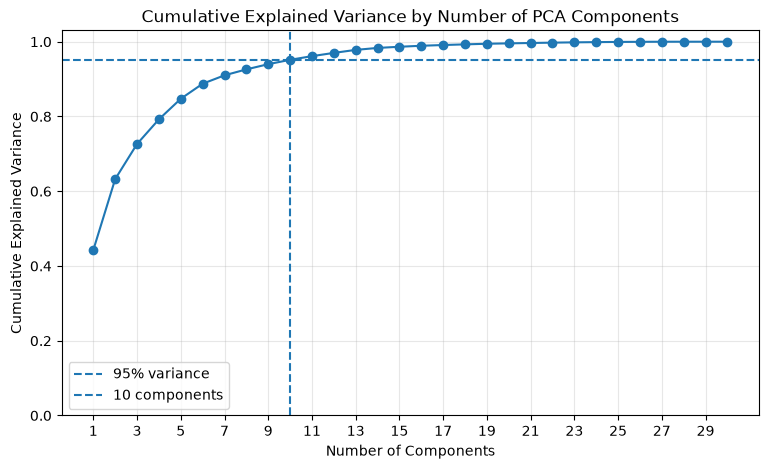

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.axvline(n_components_95, linestyle="--", label=f"{n_components_95} components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by Number of PCA Components")
plt.xticks(np.arange(1, len(cumulative_variance) + 1, 2))
plt.ylim(0, 1.03)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

For this dataset, the first **10 components** retain a little more than **95% of the total variance**. That reduces the representation from 30 original features to 10 components while keeping most of the variation present in the standardized data.

The 95% threshold is a practical choice, not a universal rule. A different task could justify keeping more or less variance depending on the importance of compression, accuracy, latency, or interpretability.

## 7. Reduce the Dataset to the Selected Number of Components

In [9]:
pca_95 = PCA(n_components=n_components_95)
X_pca_95 = pca_95.fit_transform(X_scaled)

print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_pca_95.shape}")
print(f"Total variance retained: {pca_95.explained_variance_ratio_.sum():.2%}")

Original shape: (569, 30)
Reduced shape: (569, 10)
Total variance retained: 95.16%


The number of samples stays the same. Only the feature representation changes from 30 original dimensions to 10 principal components.

This is the main compression result for the experiment.

## 8. What a Principal Component Is Made Of

Each component is a weighted combination of all original features. The weights are stored in `components_`.

Looking at the largest absolute weights for PC1 and PC2 makes this more concrete. The sign gives the direction of the relationship, while the absolute value shows how strongly that feature contributes to the component.

In [10]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=X.columns,
    columns=[f"PC{i}" for i in range(1, X.shape[1] + 1)]
)

for pc in ["PC1", "PC2"]:
    top_features = loadings[pc].abs().sort_values(ascending=False).head(6).index
    display(loadings.loc[top_features, [pc]].sort_values(pc, key=abs, ascending=False))

,PC1
mean concave points,0.260854
mean concavity,0.258400
worst concave points,0.250886
mean compactness,0.239285
worst perimeter,0.236640
worst concavity,0.228768


,PC2
mean fractal dimension,0.366575
fractal dimension error,0.280092
worst fractal dimension,0.275339
mean radius,-0.233857
compactness error,0.232716
mean area,-0.231077


This is also why PCA usually reduces direct interpretability. A component is not one original measurement such as `mean radius`; it is a combination of several measurements.

The components are useful compact features, but their meaning is less direct than the original columns.

## 9. Reduce to Two Components for Visualization

For visualization only, I fit PCA with two components. This makes every sample a point in a 2D plane.

Before interpreting the plot, I check how much variance PC1 and PC2 actually preserve together.

In [11]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

variance_pc1 = pca_2d.explained_variance_ratio_[0]
variance_pc2 = pca_2d.explained_variance_ratio_[1]
variance_2d = pca_2d.explained_variance_ratio_.sum()

print(f"PC1 explained variance: {variance_pc1:.2%}")
print(f"PC2 explained variance: {variance_pc2:.2%}")
print(f"Total variance shown in 2D: {variance_2d:.2%}")

PC1 explained variance: 44.27%
PC2 explained variance: 18.97%
Total variance shown in 2D: 63.24%


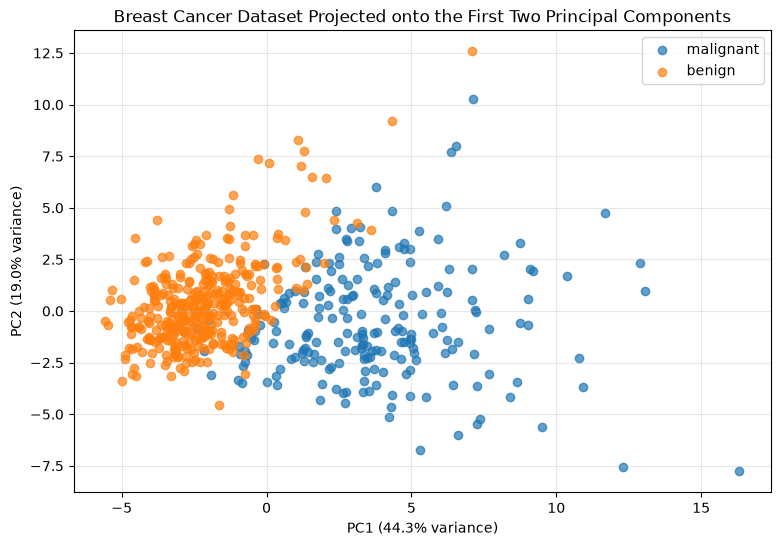

In [12]:
pca_plot = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
pca_plot["diagnosis"] = y.map({0: data.target_names[0], 1: data.target_names[1]})

plt.figure(figsize=(9, 6))

for diagnosis in data.target_names:
    subset = pca_plot[pca_plot["diagnosis"] == diagnosis]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.7,
        label=diagnosis
    )

plt.xlabel(f"PC1 ({variance_pc1:.1%} variance)")
plt.ylabel(f"PC2 ({variance_pc2:.1%} variance)")
plt.title("Breast Cancer Dataset Projected onto the First Two Principal Components")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

The first two components preserve about **63% of the total variance**, so this plot is a useful 2D view but not a complete representation of the 30-dimensional dataset.

The known diagnosis groups show visible separation in parts of the PCA space. The labels were not used to calculate the components; they are only added after PCA to help interpret the visualization.

This is important because PCA is still an unsupervised transformation: it uses `X`, not the target `y`, to find the directions of maximum variance.

## 10. What PCA Preserved and What It Cost

### What I gained

- The dataset was reduced from 30 features to 10 components while retaining a little over 95% of the variance.
- The lower-dimensional representation is smaller and can reduce computation for downstream work.
- Correlated information from multiple original features can be represented more compactly.
- A 2D PCA projection makes high-dimensional structure easier to inspect visually.

### What I lost

- The retained components do not preserve 100% of the original variance.
- The new components are combinations of many original features, so they are harder to explain directly.
- A 2D visualization discards considerably more information than the 10-component representation.
- PCA is linear, so it cannot represent every possible nonlinear structure in the data.

PCA can sometimes help downstream models by removing redundant or low-variance directions, but it does not automatically improve model accuracy or reduce overfitting. That has to be verified for the specific modeling task.

## Main Takeaway

The PCA workflow here is:

```text
High-dimensional features
        ↓
StandardScaler
        ↓
Fit PCA across all components
        ↓
Explained variance per component
        ↓
Cumulative explained variance
        ↓
Choose the smallest component count reaching ~95%
        ↓
30 features → 10 principal components
        ↓
Use PC1 + PC2 separately for 2D visualization
```

For this dataset, 10 principal components retain just over 95% of the variance. The first two components retain about 63%, which is enough to provide a useful visual summary but not enough to represent the full dataset without information loss.